# Inputs



Load the two cluster-specific Bray-Curtis dissimilarity artifacts produced by Framework 1 together with the A1 contamination-score artifact used to identify the lowest and highest contamination sites within each cluster.


In [107]:
from pathlib import Path

import pandas as pd



# Repository paths
ARTIFACT_DIR = Path("../artifacts")
RESULTS_DIR = Path("../results")
FIGURE_DIR = Path("../figures")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SITE_ID_COLUMN = "Integrated Code"

# Load the Bray-Curtis dissimilarity artifacts produced by Framework 1.
A7 = pd.read_excel(ARTIFACT_DIR / "A7_C1_bray_curtis_dissimilarity_matrix.xlsx")
A8 = pd.read_excel(ARTIFACT_DIR / "A8_C2_bray_curtis_dissimilarity_matrix.xlsx")

# Load the A1 stressor-score matrix S_c
A1 = pd.read_excel(ARTIFACT_DIR / "A1_stressors_and_scores.xlsx").reset_index(drop=True)

print(f"Loaded A1 stressor-score matrix S_c: {A1.shape[0]} rows × {A1.shape[1] - 1} stressor-score columns")
display(A1.head())
print(f"Loaded A7 cluster C1 Bray-Curtis dissimilarity matrix: {A7.shape[0]} rows × {A7.shape[1] - 1} dissimilarity columns")
display(A7.head())
print(f"Loaded A8 cluster C2 Bray-Curtis dissimilarity matrix: {A8.shape[0]} rows × {A8.shape[1] - 1} dissimilarity columns")
display(A8.head())

Loaded A1 stressor-score matrix S_c: 310 rows × 6 stressor-score columns


,Integrated Code,PC1,PC3,PC4,PC5,SumRel,MaxRel
0,DR-02,-3.576446,2.096010,-0.392204,0.327409,-1.545231,2.096010
1,DR-03,-9.212448,-3.485213,-1.269014,0.152120,-13.814555,0.152120
2,DR-04,-8.313318,0.509110,-1.422312,-0.048742,-9.275262,0.509110
3,DR-06,7.727415,3.855054,0.583084,3.001895,15.167448,7.727415
4,DR-07,-6.315431,1.386617,-1.047327,0.575785,-5.400357,1.386617


Loaded A7 cluster C1 Bray-Curtis dissimilarity matrix: 161 rows × 161 dissimilarity columns


,Integrated Code,DR-02,DR-03,DR-04,DR-07,DR-08,DR-21,DR-32,DR-163,DR-177,...,SCR-09,DR-152,DR-154,DR-156,DR-157,DR-158,DR-159,LSC-64,C1 ref pole,C1 deg pole
0,DR-02,0.000000,0.928049,0.931827,0.118827,0.940263,0.935484,0.879540,0.293907,0.935484,...,0.898009,0.876660,0.935484,0.935484,0.930329,0.944440,0.935484,0.950988,0.908915,0.923800
1,DR-03,0.928049,0.000000,0.497359,0.931113,0.115242,0.150590,0.142174,0.862454,0.474540,...,0.475522,0.819812,0.502773,0.376910,0.712969,0.753250,0.786555,0.374123,0.492179,0.770336
2,DR-04,0.931827,0.497359,0.000000,0.936349,0.530942,0.480822,0.449006,0.832066,0.448227,...,0.471483,0.819727,0.298833,0.360372,0.567879,0.525390,0.644170,0.679251,0.336170,0.607629
3,DR-07,0.118827,0.931113,0.936349,0.000000,0.942272,0.940410,0.884466,0.229050,0.940410,...,0.941341,0.879724,0.940410,0.940410,0.935255,0.974415,0.940668,0.935707,0.914724,0.928762
4,DR-08,0.940263,0.115242,0.530942,0.942272,0.000000,0.098398,0.146752,0.833333,0.425008,...,0.402735,0.867860,0.527018,0.408213,0.710444,0.784552,0.750805,0.391469,0.448164,0.721791


Loaded A8 cluster C2 Bray-Curtis dissimilarity matrix: 162 rows × 162 dissimilarity columns


,Integrated Code,DR-06,DR-09,DR-10,DR-43,DR-54,DR-65,DR-76,DR-87,DR-98,...,DR-146,DR-149,DR-150,DR-151,DR-155,LSC-65,LSC-66,LSC-67,C2 ref pole,C2 deg pole
0,DR-06,0.000000,0.460811,0.943085,0.619201,0.659804,0.930426,0.933091,0.158124,0.924736,...,0.761794,0.508480,0.933184,0.811755,0.820654,0.932853,0.934194,0.933091,0.755059,0.953052
1,DR-09,0.460811,0.000000,0.927602,0.451357,0.624030,0.927602,0.927602,0.345980,0.904728,...,0.365516,0.424208,0.922226,0.819005,0.790547,0.932127,0.918552,0.932127,0.737944,0.970684
2,DR-10,0.943085,0.927602,0.000000,0.580711,0.646645,0.309935,0.186976,0.970414,0.226022,...,0.852632,0.859557,0.710471,0.728461,0.746258,0.332164,0.397775,0.647137,0.620667,0.855459
3,DR-43,0.619201,0.451357,0.580711,0.000000,0.243132,0.480769,0.638093,0.512574,0.472565,...,0.522571,0.413462,0.600628,0.486991,0.513786,0.510945,0.623215,0.547195,0.438418,0.731353
4,DR-54,0.659804,0.624030,0.646645,0.243132,0.000000,0.380199,0.704027,0.660926,0.538499,...,0.544549,0.453297,0.446782,0.377101,0.359940,0.392857,0.645193,0.402195,0.433169,0.545832


# Analysis Parameters



Set the NMDS dimensionality grid, multistart controls, diagnostic thresholds, and output file targets used throughout the workflow.


In [108]:
CLUSTER_INPUT_ARTIFACTS = {
    "C1": "A7",
    "C2": "A8",
}

CLUSTER_REF_POLE_LABELS = {
    "C1": "C1 ref pole",
    "C2": "C2 ref pole",
}

CLUSTER_DEG_POLE_LABELS = {
    "C1": "C1 deg pole",
    "C2": "C2 deg pole",
}

NMDS_DIMENSIONS = tuple(range(1, 6))
SELECTION_DIMENSIONS = (2, 3)
NMDS_RESTARTS = 5
MAX_NMDS_ITERATIONS = 150
NMDS_TOLERANCE = 1e-5
PERTURBATION_SCALE = 1e-3
RANDOM_SEED = 20260526
PREFERRED_STRESS_THRESHOLD = 0.10
ACCEPTABLE_STRESS_THRESHOLD = 0.20
CONTAMINATION_SCORE = "SumRel"
EXTREME_SITES = 20

PAIR_TYPE_ORDER = (
    "real-to-real",
    "real-to-pole",
    "pole-to-pole",
)

PAIR_TYPE_PALETTE = {
    "real-to-real": "#7f7f7f",
    "real-to-pole": "#1f78b4",
    "pole-to-pole": "#d62728",
}

POLE_COLOR_MAP = {
    "reference": "#2ca25f",
    "degraded": "#de2d26",
}

EXTREME_SITE_COLOR_MAP = {
    "lowest": "#2b8cbe",
    "highest": "#f16913",
}

print(
    f"Framework 2 will evaluate NMDS dimensions {NMDS_DIMENSIONS} for "
    f"{len(CLUSTER_INPUT_ARTIFACTS)} cluster-specific Bray-Curtis matrices with "
    f"{NMDS_RESTARTS} restarts per dimension."
)

print(
    f"Ordination plots will highlight the {EXTREME_SITES} lowest and {EXTREME_SITES} highest "
    f"{CONTAMINATION_SCORE} sites within each cluster."
)


Framework 2 will evaluate NMDS dimensions (1, 2, 3, 4, 5) for 2 cluster-specific Bray-Curtis matrices with 5 restarts per dimension.
Ordination plots will highlight the 20 lowest and 20 highest SumRel sites within each cluster.


# Definition Corner



Define the dissimilarity-matrix loaders, NMDS solvers, diagnostic summarizers, and visualization helpers used in the downstream workflow.


In [109]:
from dataclasses import dataclass



import matplotlib.pyplot as plt

import numpy as np

from scipy.linalg import eigh

from scipy.spatial.distance import pdist, squareform

from scipy.stats import rankdata





@dataclass

class NMDSRunResult:

    configuration: pd.DataFrame

    distance_matrix: pd.DataFrame

    disparity_matrix: pd.DataFrame

    pair_table: pd.DataFrame

    stress: float

    iterations: int

    dimension: int

    restart_index: int





@dataclass

class MultistartNMDSResult:

    best_run: NMDSRunResult

    final_stresses: list[float]





def coerce_symmetric_dissimilarity_matrix(

    raw_table: pd.DataFrame,

    id_col: str = SITE_ID_COLUMN,

) -> pd.DataFrame:

    if id_col not in raw_table.columns:

        raise KeyError(f"The raw table must contain the identifier column {id_col!r}.")



    matrix = raw_table.copy()

    matrix[id_col] = matrix[id_col].astype(str)

    if matrix[id_col].duplicated().any():

        duplicated_ids = matrix.loc[matrix[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate row labels found in the raw dissimilarity table: {duplicated_ids}")



    matrix = matrix.set_index(id_col)

    matrix.columns = matrix.columns.astype(str)



    missing_columns = [label for label in matrix.index if label not in matrix.columns]

    if missing_columns:

        raise ValueError(f"Matrix columns are missing row labels: {missing_columns[:10]}")



    matrix = matrix.loc[matrix.index, matrix.index].apply(pd.to_numeric, errors="coerce")

    if matrix.isna().any().any():

        incomplete_columns = matrix.columns[matrix.isna().any()].tolist()

        raise ValueError(

            f"Dissimilarity matrix contains missing or non-numeric values in: {incomplete_columns[:10]}"

        )



    values = matrix.to_numpy(dtype=float)

    symmetric_values = 0.5 * (values + values.T)

    np.fill_diagonal(symmetric_values, 0.0)



    symmetric_matrix = pd.DataFrame(

        symmetric_values,

        index=matrix.index.astype(str),

        columns=matrix.index.astype(str),

    )

    symmetric_matrix.index.name = id_col

    symmetric_matrix.columns.name = id_col

    return symmetric_matrix





def extract_upper_triangle_pairs(dissimilarity_matrix: pd.DataFrame) -> pd.DataFrame:

    if dissimilarity_matrix.shape[0] != dissimilarity_matrix.shape[1]:

        raise ValueError("dissimilarity_matrix must be square.")



    labels = dissimilarity_matrix.index.astype(str).to_numpy()

    row_idx, col_idx = np.triu_indices(len(labels), k=1)

    upper_triangle_values = dissimilarity_matrix.to_numpy(dtype=float)[row_idx, col_idx]



    return pd.DataFrame(

        {

            "label_i": labels[row_idx],

            "label_j": labels[col_idx],

            "original_dissimilarity": upper_triangle_values,

        }

    )





def label_pair_type(

    pair_label: tuple[str, str],

    ref_pole_label: str,

    deg_pole_label: str,

) -> str:

    pole_labels = {ref_pole_label, deg_pole_label}

    pole_count = sum(label in pole_labels for label in pair_label)

    if pole_count == 2:

        return "pole-to-pole"

    if pole_count == 1:

        return "real-to-pole"

    return "real-to-real"





def annotate_pair_types(

    pair_table: pd.DataFrame,

    ref_pole_label: str,

    deg_pole_label: str,

) -> pd.DataFrame:

    annotated_table = pair_table.copy()

    annotated_table["pair_type"] = [

        label_pair_type((label_i, label_j), ref_pole_label, deg_pole_label)

        for label_i, label_j in zip(annotated_table["label_i"], annotated_table["label_j"])

    ]

    return annotated_table





def rank_pairwise_dissimilarities(dissimilarity_values) -> np.ndarray:

    return rankdata(np.asarray(dissimilarity_values, dtype=float), method="average")





def perturb_configuration(

    initial_configuration: pd.DataFrame,

    random_seed: int,

    scale: float = PERTURBATION_SCALE,

) -> pd.DataFrame:

    random_generator = np.random.default_rng(random_seed)

    noise = random_generator.normal(

        loc=0.0,

        scale=scale,

        size=initial_configuration.shape,

    )

    perturbed_values = initial_configuration.to_numpy(dtype=float) + noise

    perturbed_values -= perturbed_values.mean(axis=0, keepdims=True)

    return pd.DataFrame(

        perturbed_values,

        index=initial_configuration.index.copy(),

        columns=initial_configuration.columns.copy(),

    )





def classical_mds_initializer(

    dissimilarity_matrix: pd.DataFrame,

    target_dimensionality: int,

) -> pd.DataFrame:

    if target_dimensionality < 1:

        raise ValueError("target_dimensionality must be at least 1.")



    labels = dissimilarity_matrix.index.astype(str)

    distance_values = dissimilarity_matrix.to_numpy(dtype=float)

    sample_size = distance_values.shape[0]



    centering_matrix = np.eye(sample_size) - np.ones((sample_size, sample_size), dtype=float) / sample_size

    gram_matrix = -0.5 * centering_matrix @ (distance_values ** 2) @ centering_matrix



    eigenvalues, eigenvectors = eigh(gram_matrix)

    sort_order = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[sort_order]

    eigenvectors = eigenvectors[:, sort_order]



    positive_mask = eigenvalues > 0.0

    positive_eigenvalues = eigenvalues[positive_mask][:target_dimensionality]

    positive_eigenvectors = eigenvectors[:, positive_mask][:, :target_dimensionality]



    if positive_eigenvalues.size:

        coordinates = positive_eigenvectors * np.sqrt(positive_eigenvalues)

    else:

        coordinates = np.zeros((sample_size, 0), dtype=float)



    if coordinates.shape[1] < target_dimensionality:

        padding = np.zeros((sample_size, target_dimensionality - coordinates.shape[1]), dtype=float)

        coordinates = np.hstack([coordinates, padding])



    coordinates -= coordinates.mean(axis=0, keepdims=True)

    axis_labels = [f"NMDS Axis {axis_index + 1}" for axis_index in range(target_dimensionality)]

    return pd.DataFrame(coordinates, index=labels, columns=axis_labels)





def build_euclidean_distance_matrix(configuration: pd.DataFrame) -> pd.DataFrame:

    labels = configuration.index.astype(str)

    if configuration.shape[0] == 1:

        distance_values = np.zeros((1, 1), dtype=float)

    else:

        distance_values = squareform(pdist(configuration.to_numpy(dtype=float), metric="euclidean"))

    return pd.DataFrame(distance_values, index=labels, columns=labels)





def vector_to_symmetric_matrix(pair_values, labels) -> pd.DataFrame:

    labels = pd.Index(labels).astype(str)

    pair_values = np.asarray(pair_values, dtype=float)

    pair_count = len(labels) * (len(labels) - 1) // 2

    if pair_values.size != pair_count:

        raise ValueError(

            f"Expected {pair_count} upper-triangle values, received {pair_values.size}."

        )



    matrix_values = np.zeros((len(labels), len(labels)), dtype=float)

    row_idx, col_idx = np.triu_indices(len(labels), k=1)

    matrix_values[row_idx, col_idx] = pair_values

    matrix_values[col_idx, row_idx] = pair_values

    return pd.DataFrame(matrix_values, index=labels, columns=labels)





def pool_adjacent_violators(values, weights=None) -> np.ndarray:

    values = np.asarray(values, dtype=float)

    if weights is None:

        weights = np.ones(values.shape[0], dtype=float)

    else:

        weights = np.asarray(weights, dtype=float)



    if values.shape != weights.shape:

        raise ValueError("values and weights must have the same shape.")

    if (weights <= 0.0).any():

        raise ValueError("weights must all be positive.")



    block_values: list[float] = []

    block_weights: list[float] = []

    block_lengths: list[int] = []



    for value, weight in zip(values, weights):

        block_values.append(float(value))

        block_weights.append(float(weight))

        block_lengths.append(1)



        while len(block_values) >= 2 and block_values[-2] > block_values[-1]:

            merged_weight = block_weights[-2] + block_weights[-1]

            merged_value = (

                block_values[-2] * block_weights[-2] + block_values[-1] * block_weights[-1]

            ) / merged_weight

            merged_length = block_lengths[-2] + block_lengths[-1]



            block_values[-2:] = [merged_value]

            block_weights[-2:] = [merged_weight]

            block_lengths[-2:] = [merged_length]



    return np.repeat(np.asarray(block_values, dtype=float), block_lengths)





def fit_isotonic_disparities(current_distances, rank_positions) -> np.ndarray:

    current_distances = np.asarray(current_distances, dtype=float)

    rank_positions = np.asarray(rank_positions, dtype=float)

    if current_distances.shape != rank_positions.shape:

        raise ValueError("current_distances and rank_positions must have the same shape.")



    order = np.argsort(rank_positions, kind="mergesort")

    sorted_ranks = rank_positions[order]

    sorted_distances = current_distances[order]



    _, inverse = np.unique(sorted_ranks, return_inverse=True)

    group_counts = np.bincount(inverse).astype(float)

    group_means = np.bincount(inverse, weights=sorted_distances) / group_counts

    group_fits = pool_adjacent_violators(group_means, group_counts)

    fitted_sorted = group_fits[inverse]



    fitted_norm = np.linalg.norm(fitted_sorted)

    distance_norm = np.linalg.norm(sorted_distances)

    if fitted_norm > 0.0 and distance_norm > 0.0:

        fitted_sorted = fitted_sorted * (distance_norm / fitted_norm)



    fitted_disparities = np.empty_like(fitted_sorted)

    fitted_disparities[order] = fitted_sorted

    return fitted_disparities





def evaluate_kruskal_stress(current_distances, fitted_disparities) -> float:

    current_distances = np.asarray(current_distances, dtype=float)

    fitted_disparities = np.asarray(fitted_disparities, dtype=float)

    numerator = float(np.sum((current_distances - fitted_disparities) ** 2))

    denominator = float(np.sum(current_distances ** 2))

    if denominator <= 0.0 or not np.isfinite(denominator):

        return np.nan

    return float(np.sqrt(numerator / denominator))





def smacof_update_step(

    configuration: pd.DataFrame,

    disparity_matrix: pd.DataFrame,

    min_distance: float = 1e-8,

) -> pd.DataFrame:

    if configuration.shape[0] <= 1:

        return configuration.copy()



    current_distance_matrix = build_euclidean_distance_matrix(configuration)

    distance_values = current_distance_matrix.to_numpy(dtype=float)

    disparity_values = disparity_matrix.to_numpy(dtype=float)

    safe_distances = np.where(distance_values > min_distance, distance_values, min_distance)



    b_matrix = -disparity_values / safe_distances

    np.fill_diagonal(b_matrix, 0.0)

    np.fill_diagonal(b_matrix, -b_matrix.sum(axis=1))



    updated_values = (b_matrix @ configuration.to_numpy(dtype=float)) / configuration.shape[0]

    updated_values -= updated_values.mean(axis=0, keepdims=True)

    return pd.DataFrame(

        updated_values,

        index=configuration.index.copy(),

        columns=configuration.columns.copy(),

    )





def optimize_nmds_configuration(

    initial_configuration: pd.DataFrame,

    rank_positions,

    original_pair_table: pd.DataFrame,

    dimension: int,

    restart_index: int,

    max_iterations: int = MAX_NMDS_ITERATIONS,

    tolerance: float = NMDS_TOLERANCE,

) -> NMDSRunResult:

    configuration = initial_configuration.copy()

    previous_stress = np.inf



    for iteration in range(1, max_iterations + 1):

        distance_matrix = build_euclidean_distance_matrix(configuration)

        current_distances = extract_upper_triangle_pairs(distance_matrix)["original_dissimilarity"].to_numpy(dtype=float)

        fitted_disparities = fit_isotonic_disparities(current_distances, rank_positions)

        disparity_matrix = vector_to_symmetric_matrix(fitted_disparities, configuration.index)

        stress = evaluate_kruskal_stress(current_distances, fitted_disparities)

        if not np.isfinite(stress):

            raise ValueError("NMDS stress became non-finite during optimization.")



        pair_table = original_pair_table.copy()

        pair_table["euclidean_distance"] = current_distances

        pair_table["disparity"] = fitted_disparities

        pair_table["residual"] = current_distances - fitted_disparities



        if np.isfinite(previous_stress) and abs(previous_stress - stress) < tolerance:

            return NMDSRunResult(

                configuration=configuration,

                distance_matrix=distance_matrix,

                disparity_matrix=disparity_matrix,

                pair_table=pair_table,

                stress=stress,

                iterations=iteration,

                dimension=dimension,

                restart_index=restart_index,

            )



        configuration = smacof_update_step(configuration, disparity_matrix)

        previous_stress = stress



    distance_matrix = build_euclidean_distance_matrix(configuration)

    current_distances = extract_upper_triangle_pairs(distance_matrix)["original_dissimilarity"].to_numpy(dtype=float)

    fitted_disparities = fit_isotonic_disparities(current_distances, rank_positions)

    disparity_matrix = vector_to_symmetric_matrix(fitted_disparities, configuration.index)

    stress = evaluate_kruskal_stress(current_distances, fitted_disparities)



    pair_table = original_pair_table.copy()

    pair_table["euclidean_distance"] = current_distances

    pair_table["disparity"] = fitted_disparities

    pair_table["residual"] = current_distances - fitted_disparities



    return NMDSRunResult(

        configuration=configuration,

        distance_matrix=distance_matrix,

        disparity_matrix=disparity_matrix,

        pair_table=pair_table,

        stress=stress,

        iterations=max_iterations,

        dimension=dimension,

        restart_index=restart_index,

    )


In [110]:
def summarize_multistart_stability(final_stresses) -> dict[str, float]:

    stress_values = np.asarray(final_stresses, dtype=float)

    if stress_values.size == 0:

        return {"min": np.nan, "median": np.nan, "range": np.nan}

    return {

        "min": float(np.min(stress_values)),

        "median": float(np.median(stress_values)),

        "range": float(np.max(stress_values) - np.min(stress_values)),

    }





def extract_real_site_ids(

    dissimilarity_matrix: pd.DataFrame,

    ref_pole_label: str,

    deg_pole_label: str,

) -> pd.Index:

    matrix_labels = pd.Index(dissimilarity_matrix.index).astype(str)

    return matrix_labels[~matrix_labels.isin([ref_pole_label, deg_pole_label])]





def select_cluster_extreme_sites(

    score_table: pd.DataFrame,

    cluster_label: str,

    cluster_site_ids,

    score_col: str = CONTAMINATION_SCORE,

    extreme_site_count: int = EXTREME_SITES,

    id_col: str = SITE_ID_COLUMN,

) -> pd.DataFrame:

    if id_col not in score_table.columns:

        raise KeyError(f"The score table must contain the identifier column {id_col!r}.")

    if score_col not in score_table.columns:

        raise KeyError(f"The score table must contain the score column {score_col!r}.")

    if extreme_site_count < 1:

        raise ValueError("extreme_site_count must be at least 1.")



    cluster_site_ids = pd.Index(cluster_site_ids).astype(str).unique()

    if cluster_site_ids.empty:

        raise ValueError("cluster_site_ids must contain at least one real site label.")



    working_table = score_table[[id_col, score_col]].copy()

    working_table[id_col] = working_table[id_col].astype(str)

    if working_table[id_col].duplicated().any():

        duplicated_ids = working_table.loc[working_table[id_col].duplicated(), id_col].unique().tolist()[:5]

        raise ValueError(f"Duplicate site IDs found in the score table: {duplicated_ids}")



    cluster_score_table = working_table.loc[working_table[id_col].isin(cluster_site_ids)].copy()

    missing_site_ids = [site_id for site_id in cluster_site_ids if site_id not in set(cluster_score_table[id_col])]

    if missing_site_ids:

        raise ValueError(

            f"Requested cluster site IDs were not found in the score table: {missing_site_ids[:10]}"

        )



    cluster_score_table[score_col] = pd.to_numeric(cluster_score_table[score_col], errors="coerce")

    if cluster_score_table[score_col].isna().any():

        raise ValueError(f"The score column {score_col!r} contains missing or non-numeric values.")



    site_count = cluster_score_table.shape[0]

    site_take = min(extreme_site_count, site_count)



    lowest_sites = cluster_score_table.sort_values(score_col, ascending=True, kind="mergesort").head(site_take).copy()

    lowest_sites["Extreme Type"] = "lowest"

    lowest_sites["Extreme Rank"] = np.arange(1, lowest_sites.shape[0] + 1, dtype=int)



    highest_sites = cluster_score_table.sort_values(score_col, ascending=False, kind="mergesort").head(site_take).copy()

    highest_sites["Extreme Type"] = "highest"

    highest_sites["Extreme Rank"] = np.arange(1, highest_sites.shape[0] + 1, dtype=int)



    extreme_site_table = pd.concat([lowest_sites, highest_sites], ignore_index=True)

    extreme_site_table.insert(0, "Community Type", cluster_label)

    return extreme_site_table[["Community Type", "Extreme Type", "Extreme Rank", id_col, score_col]]





def run_multistart_nmds(

    dissimilarity_matrix: pd.DataFrame,

    target_dimensionality: int,

    original_pair_table: pd.DataFrame,

    rank_positions,

    n_restarts: int = NMDS_RESTARTS,

    base_seed: int = RANDOM_SEED,

    perturbation_scale: float = PERTURBATION_SCALE,

    max_iterations: int = MAX_NMDS_ITERATIONS,

    tolerance: float = NMDS_TOLERANCE,

) -> MultistartNMDSResult:

    if n_restarts < 1:

        raise ValueError("n_restarts must be at least 1.")



    base_configuration = classical_mds_initializer(dissimilarity_matrix, target_dimensionality)

    run_results: list[NMDSRunResult] = []



    for restart_index in range(1, n_restarts + 1):

        if restart_index == 1:

            initial_configuration = base_configuration.copy()

        else:

            initial_configuration = perturb_configuration(

                base_configuration,

                random_seed=base_seed + 1000 * target_dimensionality + restart_index,

                scale=perturbation_scale,

            )



        run_result = optimize_nmds_configuration(

            initial_configuration=initial_configuration,

            rank_positions=rank_positions,

            original_pair_table=original_pair_table,

            dimension=target_dimensionality,

            restart_index=restart_index,

            max_iterations=max_iterations,

            tolerance=tolerance,

        )

        run_results.append(run_result)



    best_run = min(run_results, key=lambda run_result: run_result.stress)

    return MultistartNMDSResult(

        best_run=best_run,

        final_stresses=[float(run_result.stress) for run_result in run_results],

    )





def select_nmds_dimensionality(

    stress_by_dimension: dict[int, float],

    candidate_dimensions: tuple[int, ...] = SELECTION_DIMENSIONS,

    preferred_threshold: float = PREFERRED_STRESS_THRESHOLD,

    acceptable_threshold: float = ACCEPTABLE_STRESS_THRESHOLD,

) -> int:

    candidate_stresses = {

        dimension: stress_by_dimension[dimension]

        for dimension in candidate_dimensions

        if dimension in stress_by_dimension

    }



    preferred_dimensions = [

        dimension

        for dimension, stress in sorted(candidate_stresses.items())

        if np.isfinite(stress) and stress < preferred_threshold

    ]

    if preferred_dimensions:

        return preferred_dimensions[0]



    acceptable_dimensions = [

        dimension

        for dimension, stress in sorted(candidate_stresses.items())

        if np.isfinite(stress) and stress < acceptable_threshold

    ]

    if acceptable_dimensions:

        return acceptable_dimensions[0]



    if candidate_stresses:

        return min(candidate_stresses, key=lambda dimension: (candidate_stresses[dimension], dimension))

    return min(stress_by_dimension, key=lambda dimension: (stress_by_dimension[dimension], dimension))





def summarize_stratified_residuals(

    pair_table: pd.DataFrame,

    cluster_label: str,

    pair_type_order: tuple[str, ...] = PAIR_TYPE_ORDER,

) -> pd.DataFrame:

    summary_records: list[dict[str, object]] = []

    for pair_type in pair_type_order:

        residuals = pair_table.loc[pair_table["pair_type"] == pair_type, "residual"].abs().to_numpy(dtype=float)

        if residuals.size:

            q1, q3 = np.quantile(residuals, [0.25, 0.75])

            median_abs_residual = float(np.median(residuals))

            iqr_abs_residual = float(q3 - q1)

            max_abs_residual = float(np.max(residuals))

        else:

            median_abs_residual = np.nan

            iqr_abs_residual = np.nan

            max_abs_residual = np.nan



        summary_records.append(

            {

                "Community Type": cluster_label,

                "Pair Type": pair_type,

                "Count": int(residuals.size),

                "Median |Residual|": median_abs_residual,

                "IQR |Residual|": iqr_abs_residual,

                "Max |Residual|": max_abs_residual,

            }

        )



    return pd.DataFrame(summary_records)





def extract_pole_geometry(

    configuration: pd.DataFrame,

    cluster_label: str,

    ref_pole_label: str,

    deg_pole_label: str,

    q_max: int,

) -> dict[str, object]:

    if ref_pole_label not in configuration.index:

        raise KeyError(f"Reference pole label {ref_pole_label!r} was not found in the configuration index.")

    if deg_pole_label not in configuration.index:

        raise KeyError(f"Degraded pole label {deg_pole_label!r} was not found in the configuration index.")



    reference_coordinates = configuration.loc[ref_pole_label].to_numpy(dtype=float)

    degraded_coordinates = configuration.loc[deg_pole_label].to_numpy(dtype=float)



    geometry_record: dict[str, object] = {"Community Type": cluster_label}

    for axis_index in range(1, q_max + 1):

        geometry_record[f"Reference Axis {axis_index}"] = (

            float(reference_coordinates[axis_index - 1])

            if axis_index <= reference_coordinates.size

            else np.nan

        )

        geometry_record[f"Degraded Axis {axis_index}"] = (

            float(degraded_coordinates[axis_index - 1])

            if axis_index <= degraded_coordinates.size

            else np.nan

        )



    geometry_record["Projection Axis Length"] = float(

        np.linalg.norm(degraded_coordinates - reference_coordinates)

    )

    return geometry_record





def build_configuration_artifact_table(

    configuration: pd.DataFrame,

    id_col: str = SITE_ID_COLUMN,

) -> pd.DataFrame:

    artifact_table = configuration.copy()

    artifact_table.insert(0, id_col, artifact_table.index.astype(str))

    return artifact_table.reset_index(drop=True)





def run_cluster_nmds_workflow(

    cluster_label: str,

    dissimilarity_matrix: pd.DataFrame,

    ref_pole_label: str,

    deg_pole_label: str,

    dimensions: tuple[int, ...] = NMDS_DIMENSIONS,

    selection_dimensions: tuple[int, ...] = SELECTION_DIMENSIONS,

    n_restarts: int = NMDS_RESTARTS,

    base_seed: int = RANDOM_SEED,

    perturbation_scale: float = PERTURBATION_SCALE,

    max_iterations: int = MAX_NMDS_ITERATIONS,

    tolerance: float = NMDS_TOLERANCE,

    preferred_threshold: float = PREFERRED_STRESS_THRESHOLD,

    acceptable_threshold: float = ACCEPTABLE_STRESS_THRESHOLD,

) -> dict[str, object]:

    base_pair_table = annotate_pair_types(

        extract_upper_triangle_pairs(dissimilarity_matrix),

        ref_pole_label=ref_pole_label,

        deg_pole_label=deg_pole_label,

    )

    base_pair_table["rank"] = rank_pairwise_dissimilarities(

        base_pair_table["original_dissimilarity"].to_numpy(dtype=float)

    )



    multistart_results: dict[int, MultistartNMDSResult] = {}

    stress_profile_records: list[dict[str, object]] = []



    for dimension in dimensions:

        multistart_result = run_multistart_nmds(

            dissimilarity_matrix=dissimilarity_matrix,

            target_dimensionality=dimension,

            original_pair_table=base_pair_table,

            rank_positions=base_pair_table["rank"].to_numpy(dtype=float),

            n_restarts=n_restarts,

            base_seed=base_seed,

            perturbation_scale=perturbation_scale,

            max_iterations=max_iterations,

            tolerance=tolerance,

        )

        multistart_results[dimension] = multistart_result



        stability_summary = summarize_multistart_stability(multistart_result.final_stresses)

        stress_profile_records.append(

            {

                "Community Type": cluster_label,

                "Dimension": dimension,

                "Final Stress": float(multistart_result.best_run.stress),

                "Restart Min Stress": stability_summary["min"],

                "Restart Median Stress": stability_summary["median"],

                "Restart Stress Range": stability_summary["range"],

            }

        )



    stress_by_dimension = {

        dimension: multistart_result.best_run.stress

        for dimension, multistart_result in multistart_results.items()

    }

    selected_dimension = select_nmds_dimensionality(

        stress_by_dimension,

        candidate_dimensions=selection_dimensions,

        preferred_threshold=preferred_threshold,

        acceptable_threshold=acceptable_threshold,

    )

    selected_multistart = multistart_results[selected_dimension]



    return {

        "dissimilarity_matrix": dissimilarity_matrix,

        "base_pair_table": base_pair_table,

        "multistart_results": multistart_results,

        "stress_profile": pd.DataFrame(stress_profile_records),

        "selected_dimension": selected_dimension,

        "selected_run": selected_multistart.best_run,

        "selected_stability": summarize_multistart_stability(selected_multistart.final_stresses),

        "residual_summary": summarize_stratified_residuals(

            selected_multistart.best_run.pair_table,

            cluster_label=cluster_label,

        ),

        "pole_geometry": extract_pole_geometry(

            configuration=selected_multistart.best_run.configuration,

            cluster_label=cluster_label,

            ref_pole_label=ref_pole_label,

            deg_pole_label=deg_pole_label,

            q_max=max(dimensions),

        ),

    }





def render_shepard_diagram_figure(

    cluster_reports: dict[str, dict[str, object]],

    pair_type_palette: dict[str, str] = PAIR_TYPE_PALETTE,

    pair_type_order: tuple[str, ...] = PAIR_TYPE_ORDER,

    dpi: int = 300,

) -> tuple[plt.Figure, np.ndarray]:

    cluster_labels = list(cluster_reports.keys())

    figure, axes = plt.subplots(1, len(cluster_labels), figsize=(8 * len(cluster_labels), 5.5), dpi=dpi)

    axes = np.atleast_1d(axes)



    for axis, cluster_label in zip(axes, cluster_labels):

        pair_table = cluster_reports[cluster_label]["selected_run"].pair_table.copy()

        for pair_type in pair_type_order:

            subset = pair_table.loc[pair_table["pair_type"] == pair_type]

            if subset.empty:

                continue

            axis.scatter(

                subset["original_dissimilarity"],

                subset["euclidean_distance"],

                s=18,

                alpha=0.65,

                color=pair_type_palette[pair_type],

                edgecolor="none",

                label=pair_type,

            )



        disparity_curve = pair_table.sort_values(

            ["original_dissimilarity", "rank"],

            kind="mergesort",

        )

        axis.plot(

            disparity_curve["original_dissimilarity"],

            disparity_curve["disparity"],

            color="black",

            linewidth=2.0,

            label="monotone disparity",

        )

        axis.set_xlabel("Original Bray-Curtis dissimilarity", fontsize=11, fontweight="bold")

        axis.set_ylabel("Ordination Euclidean distance", fontsize=11, fontweight="bold")

        axis.set_title(

            f"{cluster_label} Shepard Diagram\nStress = {cluster_reports[cluster_label]['selected_run'].stress:.3f}",

            fontsize=13,

            fontweight="bold",

        )

        axis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)

        axis.set_axisbelow(True)



    handles, labels = axes[0].get_legend_handles_labels()

    figure.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

    figure.tight_layout(rect=(0, 0.08, 1, 1))

    return figure, axes





def render_stress_scree_figure(

    cluster_reports: dict[str, dict[str, object]],

    preferred_threshold: float = PREFERRED_STRESS_THRESHOLD,

    acceptable_threshold: float = ACCEPTABLE_STRESS_THRESHOLD,

    dpi: int = 300,

) -> tuple[plt.Figure, np.ndarray]:

    cluster_labels = list(cluster_reports.keys())

    figure, axes = plt.subplots(1, len(cluster_labels), figsize=(7.5 * len(cluster_labels), 4.8), dpi=dpi)

    axes = np.atleast_1d(axes)



    for axis, cluster_label in zip(axes, cluster_labels):

        stress_profile = cluster_reports[cluster_label]["stress_profile"].sort_values("Dimension")

        axis.plot(

            stress_profile["Dimension"],

            stress_profile["Final Stress"],

            marker="o",

            linewidth=2.0,

            color="#1f78b4",

        )

        axis.axhline(preferred_threshold, color="#2ca25f", linestyle="--", linewidth=1.2)

        axis.axhline(acceptable_threshold, color="#de2d26", linestyle="--", linewidth=1.2)

        axis.set_xticks(stress_profile["Dimension"])

        axis.set_xlabel("Ordination dimensionality", fontsize=11, fontweight="bold")

        axis.set_ylabel("Final stress", fontsize=11, fontweight="bold")

        axis.set_title(f"{cluster_label} Stress Scree", fontsize=13, fontweight="bold")

        axis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)

        axis.set_axisbelow(True)



    figure.tight_layout()

    return figure, axes





def render_ordination_figure(

    cluster_reports: dict[str, dict[str, object]],

    cluster_extreme_site_tables: dict[str, pd.DataFrame] | None = None,

    ref_pole_labels: dict[str, str] = CLUSTER_REF_POLE_LABELS,

    deg_pole_labels: dict[str, str] = CLUSTER_DEG_POLE_LABELS,

    pole_color_map: dict[str, str] = POLE_COLOR_MAP,

    extreme_site_color_map: dict[str, str] = EXTREME_SITE_COLOR_MAP,

    score_col: str = CONTAMINATION_SCORE,

    id_col: str = SITE_ID_COLUMN,

    dpi: int = 300,

) -> tuple[plt.Figure, np.ndarray]:

    cluster_extreme_site_tables = cluster_extreme_site_tables or {}

    cluster_labels = list(cluster_reports.keys())

    figure, axes = plt.subplots(1, len(cluster_labels), figsize=(7.5 * len(cluster_labels), 6.0), dpi=dpi)

    axes = np.atleast_1d(axes)



    for axis, cluster_label in zip(axes, cluster_labels):

        configuration = cluster_reports[cluster_label]["selected_run"].configuration.copy()

        x_coordinates = configuration.iloc[:, 0].to_numpy(dtype=float)

        if configuration.shape[1] > 1:

            y_coordinates = configuration.iloc[:, 1].to_numpy(dtype=float)

            y_label = "NMDS Axis 2"

        else:

            y_coordinates = np.zeros(configuration.shape[0], dtype=float)

            y_label = "NMDS Axis 2 (zero baseline)"



        ref_label = ref_pole_labels[cluster_label]

        deg_label = deg_pole_labels[cluster_label]

        real_site_mask = ~configuration.index.isin([ref_label, deg_label])



        extreme_site_table = cluster_extreme_site_tables.get(cluster_label)

        lowest_site_ids: set[str] = set()

        highest_site_ids: set[str] = set()

        if extreme_site_table is not None and not extreme_site_table.empty:

            lowest_site_ids = set(

                extreme_site_table.loc[extreme_site_table["Extreme Type"] == "lowest", id_col].astype(str)

            )

            highest_site_ids = set(

                extreme_site_table.loc[extreme_site_table["Extreme Type"] == "highest", id_col].astype(str)

            )



        lowest_site_mask = configuration.index.isin(sorted(lowest_site_ids))

        highest_site_mask = configuration.index.isin(sorted(highest_site_ids))

        baseline_site_mask = real_site_mask & ~lowest_site_mask & ~highest_site_mask



        axis.scatter(

            x_coordinates[baseline_site_mask],

            y_coordinates[baseline_site_mask],

            s=30,

            color="#bdbdbd",

            alpha=0.65,

            edgecolor="white",

            linewidth=0.3,

            label="Other cluster sites",

        )

        if np.any(lowest_site_mask):

            axis.scatter(

                x_coordinates[lowest_site_mask],

                y_coordinates[lowest_site_mask],

                s=48,

                color=extreme_site_color_map["lowest"],

                alpha=0.9,

                edgecolor="black",

                linewidth=0.35,

                label=f"Lowest {EXTREME_SITES} {score_col}",

                zorder=2,

            )

        if np.any(highest_site_mask):

            axis.scatter(

                x_coordinates[highest_site_mask],

                y_coordinates[highest_site_mask],

                s=48,

                color=extreme_site_color_map["highest"],

                alpha=0.9,

                edgecolor="black",

                linewidth=0.35,

                label=f"Highest {EXTREME_SITES} {score_col}",

                zorder=2,

            )



        reference_coordinates = configuration.loc[ref_label].to_numpy(dtype=float)

        degraded_coordinates = configuration.loc[deg_label].to_numpy(dtype=float)

        reference_y = reference_coordinates[1] if reference_coordinates.size > 1 else 0.0

        degraded_y = degraded_coordinates[1] if degraded_coordinates.size > 1 else 0.0



        axis.scatter(

            [reference_coordinates[0]],

            [reference_y],

            marker="*",

            s=220,

            color=pole_color_map["reference"],

            edgecolor="black",

            linewidth=0.7,

            label="Reference pole",

            zorder=3,

        )

        axis.scatter(

            [degraded_coordinates[0]],

            [degraded_y],

            marker="*",

            s=220,

            color=pole_color_map["degraded"],

            edgecolor="black",

            linewidth=0.7,

            label="Degraded pole",

            zorder=3,

        )

        axis.plot(

            [reference_coordinates[0], degraded_coordinates[0]],

            [reference_y, degraded_y],

            color="black",

            linewidth=1.5,

            linestyle="-",

        )

        axis.annotate(ref_label, (reference_coordinates[0], reference_y), xytext=(8, 8), textcoords="offset points")

        axis.annotate(deg_label, (degraded_coordinates[0], degraded_y), xytext=(8, 8), textcoords="offset points")



        axis.set_xlabel("NMDS Axis 1", fontsize=11, fontweight="bold")

        axis.set_ylabel(y_label, fontsize=11, fontweight="bold")

        axis.set_title(

            f"{cluster_label} Final NMDS Ordination\nq = {cluster_reports[cluster_label]['selected_dimension']}, Stress = {cluster_reports[cluster_label]['selected_run'].stress:.3f}",

            fontsize=13,

            fontweight="bold",

        )

        axis.axhline(0.0, color="#d9d9d9", linewidth=0.8)

        axis.axvline(0.0, color="#d9d9d9", linewidth=0.8)

        axis.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)

        axis.set_axisbelow(True)

        axis.set_aspect("equal", adjustable="datalim")



    handles, labels = axes[0].get_legend_handles_labels()

    figure.legend(handles, labels, loc="lower center", ncol=min(5, len(labels)), frameon=False)

    figure.tight_layout(rect=(0, 0.08, 1, 1))

    return figure, axes


# Process



Run the multistart NMDS analyses for the C1 and C2 Bray-Curtis matrices, assemble the per-cluster summaries, and materialize the output artifacts.


In [111]:
cluster_raw_tables = {

    "C1": A7,

    "C2": A8,

}



cluster_dissimilarity_matrices = {

    cluster_label: coerce_symmetric_dissimilarity_matrix(raw_table, id_col=SITE_ID_COLUMN)

    for cluster_label, raw_table in cluster_raw_tables.items()

}



cluster_extreme_site_tables = {

    cluster_label: select_cluster_extreme_sites(

        score_table=A1,

        cluster_label=cluster_label,

        cluster_site_ids=extract_real_site_ids(

            cluster_dissimilarity_matrices[cluster_label],

            ref_pole_label=CLUSTER_REF_POLE_LABELS[cluster_label],

            deg_pole_label=CLUSTER_DEG_POLE_LABELS[cluster_label],

        ),

        score_col=CONTAMINATION_SCORE,

        extreme_site_count=EXTREME_SITES,

        id_col=SITE_ID_COLUMN,

    )

    for cluster_label in CLUSTER_INPUT_ARTIFACTS

}

extreme_site_summary_table = pd.concat(

    [cluster_extreme_site_tables[cluster_label] for cluster_label in CLUSTER_INPUT_ARTIFACTS],

    ignore_index=True,

)

extreme_site_summary_table["Extreme Type"] = pd.Categorical(

    extreme_site_summary_table["Extreme Type"],

    categories=["lowest", "highest"],

    ordered=True,

)

extreme_site_summary_table = extreme_site_summary_table.sort_values(

    ["Community Type", "Extreme Type", "Extreme Rank"]

).reset_index(drop=True)

extreme_site_summary_table["Extreme Type"] = extreme_site_summary_table["Extreme Type"].astype(str)



cluster_nmds_reports: dict[str, dict[str, object]] = {}

for cluster_label in CLUSTER_INPUT_ARTIFACTS:

    cluster_nmds_reports[cluster_label] = run_cluster_nmds_workflow(

        cluster_label=cluster_label,

        dissimilarity_matrix=cluster_dissimilarity_matrices[cluster_label],

        ref_pole_label=CLUSTER_REF_POLE_LABELS[cluster_label],

        deg_pole_label=CLUSTER_DEG_POLE_LABELS[cluster_label],

        dimensions=NMDS_DIMENSIONS,

        selection_dimensions=SELECTION_DIMENSIONS,

        n_restarts=NMDS_RESTARTS,

        base_seed=RANDOM_SEED,

        perturbation_scale=PERTURBATION_SCALE,

        max_iterations=MAX_NMDS_ITERATIONS,

        tolerance=NMDS_TOLERANCE,

        preferred_threshold=PREFERRED_STRESS_THRESHOLD,

        acceptable_threshold=ACCEPTABLE_STRESS_THRESHOLD,

    )



nmds_fit_summary_table = pd.DataFrame(

    [

        {

            "Community Type": cluster_label,

            "Selected Dimensions": report["selected_dimension"],

            "Final Stress": float(report["selected_run"].stress),

            "Stress Range Across Restarts": float(report["selected_stability"]["range"]),

            "Iterations to Convergence": int(report["selected_run"].iterations),

        }

        for cluster_label, report in cluster_nmds_reports.items()

    ]

).sort_values("Community Type").reset_index(drop=True)



stratified_residual_summary_table = pd.concat(

    [report["residual_summary"] for report in cluster_nmds_reports.values()],

    ignore_index=True,

)

stratified_residual_summary_table["Pair Type"] = pd.Categorical(

    stratified_residual_summary_table["Pair Type"],

    categories=PAIR_TYPE_ORDER,

    ordered=True,

)

stratified_residual_summary_table = stratified_residual_summary_table.sort_values(

    ["Community Type", "Pair Type"]

).reset_index(drop=True)

stratified_residual_summary_table["Pair Type"] = stratified_residual_summary_table["Pair Type"].astype(str)



pole_geometry_table = pd.DataFrame(

    [report["pole_geometry"] for report in cluster_nmds_reports.values()]

).sort_values("Community Type").reset_index(drop=True)



stress_profile_table = pd.concat(

    [report["stress_profile"] for report in cluster_nmds_reports.values()],

    ignore_index=True,

).sort_values(["Community Type", "Dimension"]).reset_index(drop=True)



selected_configuration_tables = {

    cluster_label: build_configuration_artifact_table(

        report["selected_run"].configuration,

        id_col=SITE_ID_COLUMN,

    )

    for cluster_label, report in cluster_nmds_reports.items()

}


In [112]:
for cluster_label, configuration_table in selected_configuration_tables.items():

    configuration_table.to_excel(CLUSTER_OUTPUT_CONFIGURATION_PATHS[cluster_label], index=False)



nmds_fit_summary_table.to_excel(FIT_SUMMARY_OUTPUT_PATH, index=False)

stratified_residual_summary_table.to_excel(RESIDUAL_SUMMARY_OUTPUT_PATH, index=False)

pole_geometry_table.to_excel(POLE_GEOMETRY_OUTPUT_PATH, index=False)

stress_profile_table.to_excel(STRESS_PROFILE_OUTPUT_PATH, index=False)



with plt.ioff():

    shepard_diagram_figure, shepard_diagram_axes = render_shepard_diagram_figure(cluster_nmds_reports)

    stress_scree_figure, stress_scree_axes = render_stress_scree_figure(cluster_nmds_reports)

    ordination_figure, ordination_axes = render_ordination_figure(

        cluster_nmds_reports,

        cluster_extreme_site_tables=cluster_extreme_site_tables,

        score_col=CONTAMINATION_SCORE,

    )



    shepard_diagram_figure.savefig(SHEPARD_FIGURE_OUTPUT_PATH, bbox_inches="tight")

    stress_scree_figure.savefig(STRESS_SCREE_FIGURE_OUTPUT_PATH, bbox_inches="tight")

    ordination_figure.savefig(ORDINATION_FIGURE_OUTPUT_PATH, bbox_inches="tight")



plt.close(shepard_diagram_figure)

plt.close(stress_scree_figure)

plt.close(ordination_figure)



framework2_saved_outputs = pd.DataFrame(

    [

        {

            "Output": "C1 NMDS configuration artifact",

            "Path": str(CLUSTER_OUTPUT_CONFIGURATION_PATHS["C1"]),

        },

        {

            "Output": "C2 NMDS configuration artifact",

            "Path": str(CLUSTER_OUTPUT_CONFIGURATION_PATHS["C2"]),

        },

        {"Output": "NMDS fit summary table", "Path": str(FIT_SUMMARY_OUTPUT_PATH)},

        {"Output": "Residual summary table", "Path": str(RESIDUAL_SUMMARY_OUTPUT_PATH)},

        {"Output": "Pole geometry table", "Path": str(POLE_GEOMETRY_OUTPUT_PATH)},

        {"Output": "Stress profile table", "Path": str(STRESS_PROFILE_OUTPUT_PATH)},

        {"Output": "Shepard diagram figure", "Path": str(SHEPARD_FIGURE_OUTPUT_PATH)},

        {"Output": "Stress scree figure", "Path": str(STRESS_SCREE_FIGURE_OUTPUT_PATH)},

        {"Output": "Ordination figure", "Path": str(ORDINATION_FIGURE_OUTPUT_PATH)},

    ]

)


# Outputs



Display the NMDS summary tables, the dimensionality profile, and previews of the finalized ordination configuration artifacts generated in the Process section.


In [113]:
print(

    f"Per-cluster NMDS fit summary; Shape: {nmds_fit_summary_table.shape[0]} clusters × "

    f"{nmds_fit_summary_table.shape[1]} columns"

)

display(nmds_fit_summary_table)



print(

    f"Cluster extreme-site contamination summary by {CONTAMINATION_SCORE}; Shape: "

    f"{extreme_site_summary_table.shape[0]} rows × {extreme_site_summary_table.shape[1]} columns"

)

display(extreme_site_summary_table)



print(

    f"Stratified residual summary; Shape: {stratified_residual_summary_table.shape[0]} rows × "

    f"{stratified_residual_summary_table.shape[1]} columns"

)

display(stratified_residual_summary_table)



print(

    f"Pole geometry summary; Shape: {pole_geometry_table.shape[0]} clusters × "

    f"{pole_geometry_table.shape[1]} columns"

)

display(pole_geometry_table)



print(

    f"Stress-by-dimensionality summary; Shape: {stress_profile_table.shape[0]} rows × "

    f"{stress_profile_table.shape[1]} columns"

)

display(stress_profile_table)



for cluster_label in CLUSTER_INPUT_ARTIFACTS:

    configuration_table = selected_configuration_tables[cluster_label]

    print(

        f"{cluster_label} finalized NMDS configuration artifact preview; Shape: "

        f"{configuration_table.shape[0]} rows × {configuration_table.shape[1] - 1} NMDS axes"

    )

    display(configuration_table.head())



print(

    f"Saved output inventory; Shape: {framework2_saved_outputs.shape[0]} outputs × "

    f"{framework2_saved_outputs.shape[1]} columns"

)

display(framework2_saved_outputs)


Per-cluster NMDS fit summary; Shape: 2 clusters × 5 columns


,Community Type,Selected Dimensions,Final Stress,Stress Range Across Restarts,Iterations to Convergence
0,C1,3,0.089939,0.000108,145
1,C2,3,0.076516,0.000003,78


Cluster extreme-site contamination summary by SumRel; Shape: 80 rows × 5 columns


,Community Type,Extreme Type,Extreme Rank,Integrated Code,SumRel
0,C1,lowest,1,LSC-26,-24.053434
1,C1,lowest,2,LSC-53,-23.345426
2,C1,lowest,3,LSC-41,-21.084456
3,C1,lowest,4,LSC-40,-20.323599
4,C1,lowest,5,LSC-19,-19.974151
...,...,...,...,...,...
75,C2,highest,16,DR-118,14.815938
76,C2,highest,17,DR-67,14.007083
77,C2,highest,18,DR-13,12.754945
78,C2,highest,19,DR-128,12.612094


Stratified residual summary; Shape: 6 rows × 6 columns


...

,Integrated Code,NMDS Axis 1,NMDS Axis 2,NMDS Axis 3
0,DR-02,-0.141441,0.341085,-0.153749
1,DR-03,-0.184451,-0.110649,0.003060
2,DR-04,-0.061556,-0.012998,0.134793
3,DR-07,-0.160880,0.352598,-0.139104
4,DR-08,-0.157342,-0.136802,-0.046372


C2 finalized NMDS configuration artifact preview; Shape: 162 rows × 3 NMDS axes


,Integrated Code,NMDS Axis 1,NMDS Axis 2,NMDS Axis 3
0,DR-06,-0.445242,-0.085649,0.113153
1,DR-09,-0.448380,0.026816,-0.121239
2,DR-10,0.070774,0.408533,0.091890
3,DR-43,-0.150589,0.120289,0.011162
4,DR-54,-0.044811,0.050870,-0.006626


Saved output inventory; Shape: 9 outputs × 2 columns


,Output,Path
0,C1 NMDS configuration artifact,../artifacts/A9_C1_nmds_configuration.xlsx
1,C2 NMDS configuration artifact,../artifacts/A10_C2_nmds_configuration.xlsx
2,NMDS fit summary table,../results/ch4_framework2_nmds_fit_summary.xlsx
3,Residual summary table,../results/ch4_framework2_residual_summary.xlsx
4,Pole geometry table,../results/ch4_framework2_pole_geometry.xlsx
5,Stress profile table,../results/ch4_framework2_stress_profile.xlsx
6,Shepard diagram figure,../figures/ch4_framework2_shepard_diagrams.png
7,Stress scree figure,../figures/ch4_framework2_stress_scree.png
8,Ordination figure,../figures/ch4_framework2_ordination_panels.png


# Visualization



Display the Shepard diagrams, stress scree panels, and finalized 2D ordination plots that were constructed in the Process section, with the lowest and highest contamination-score sites highlighted within each cluster.


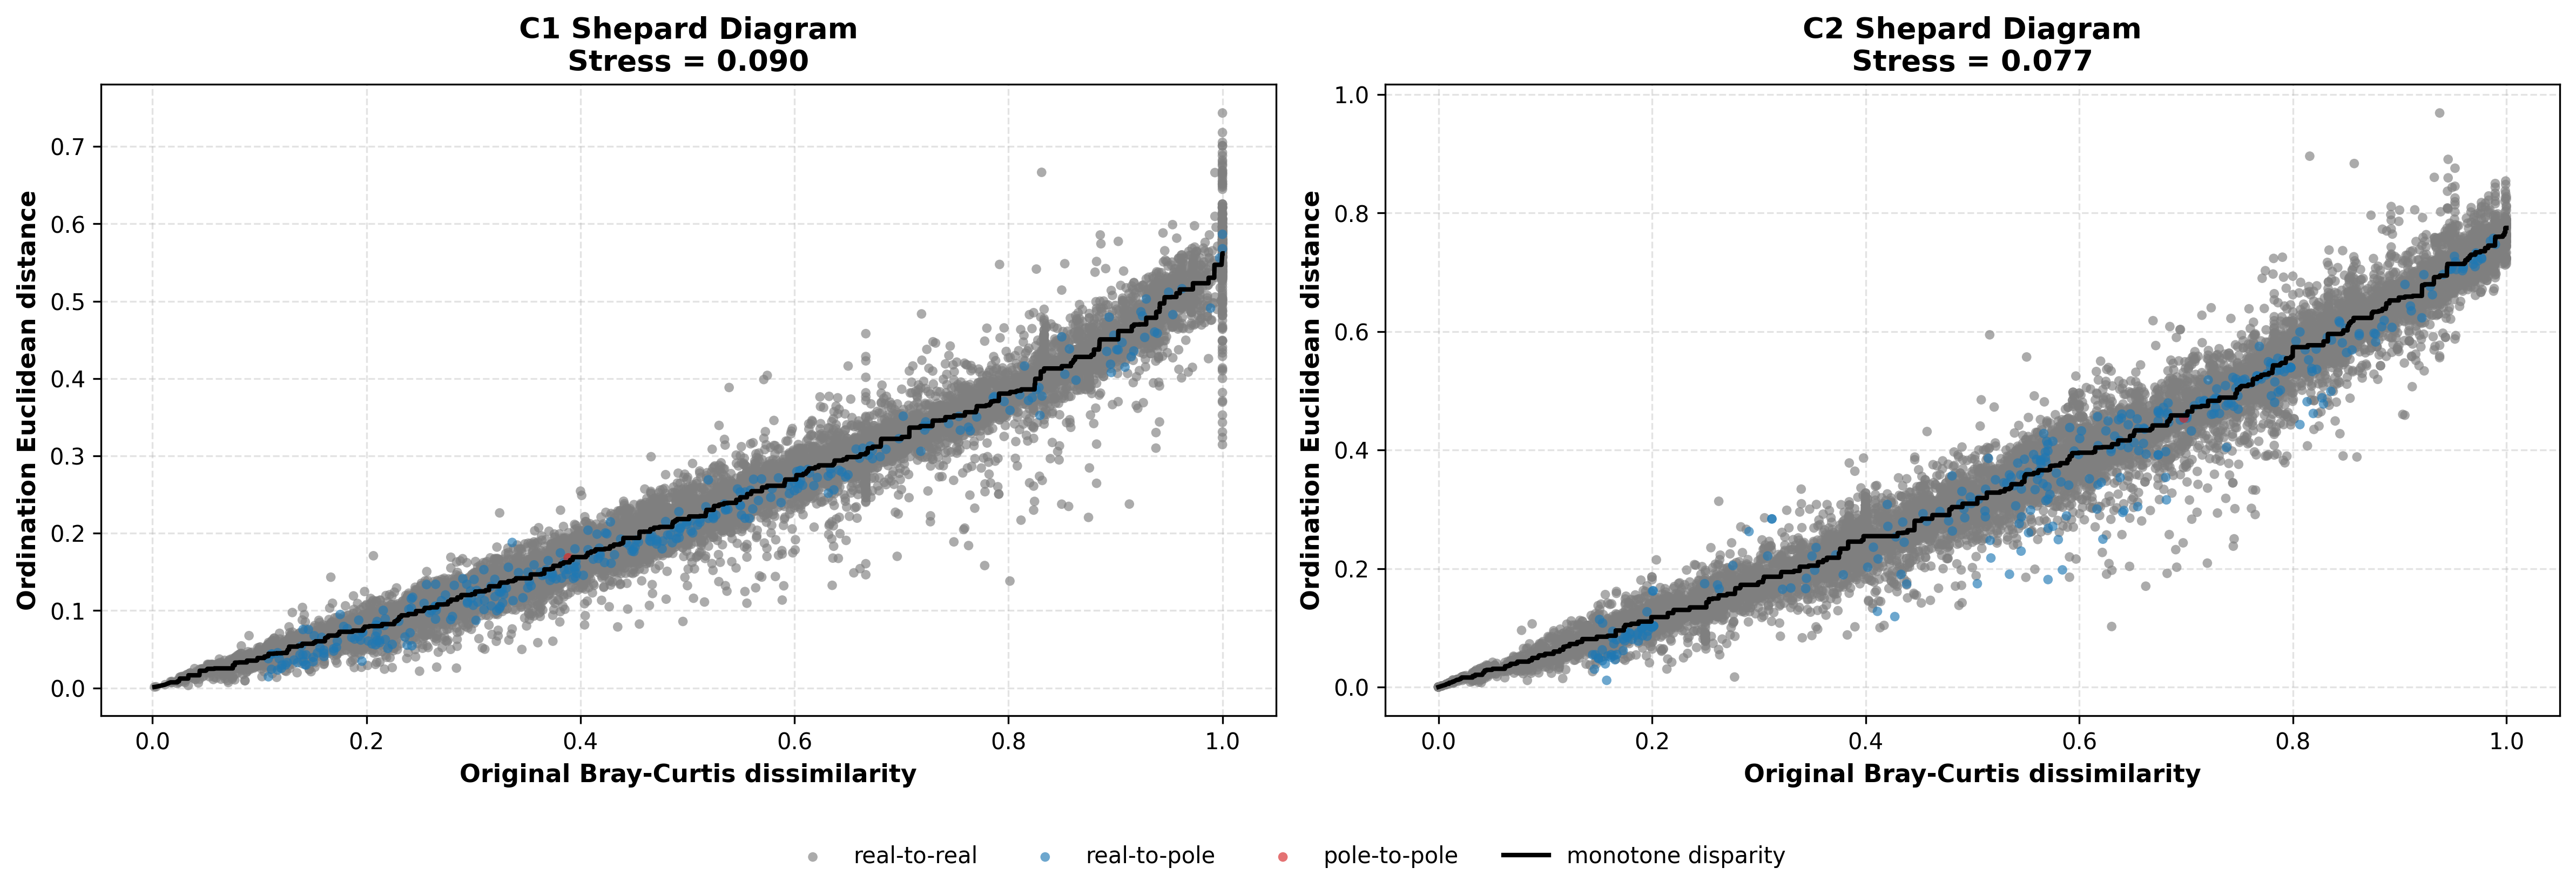

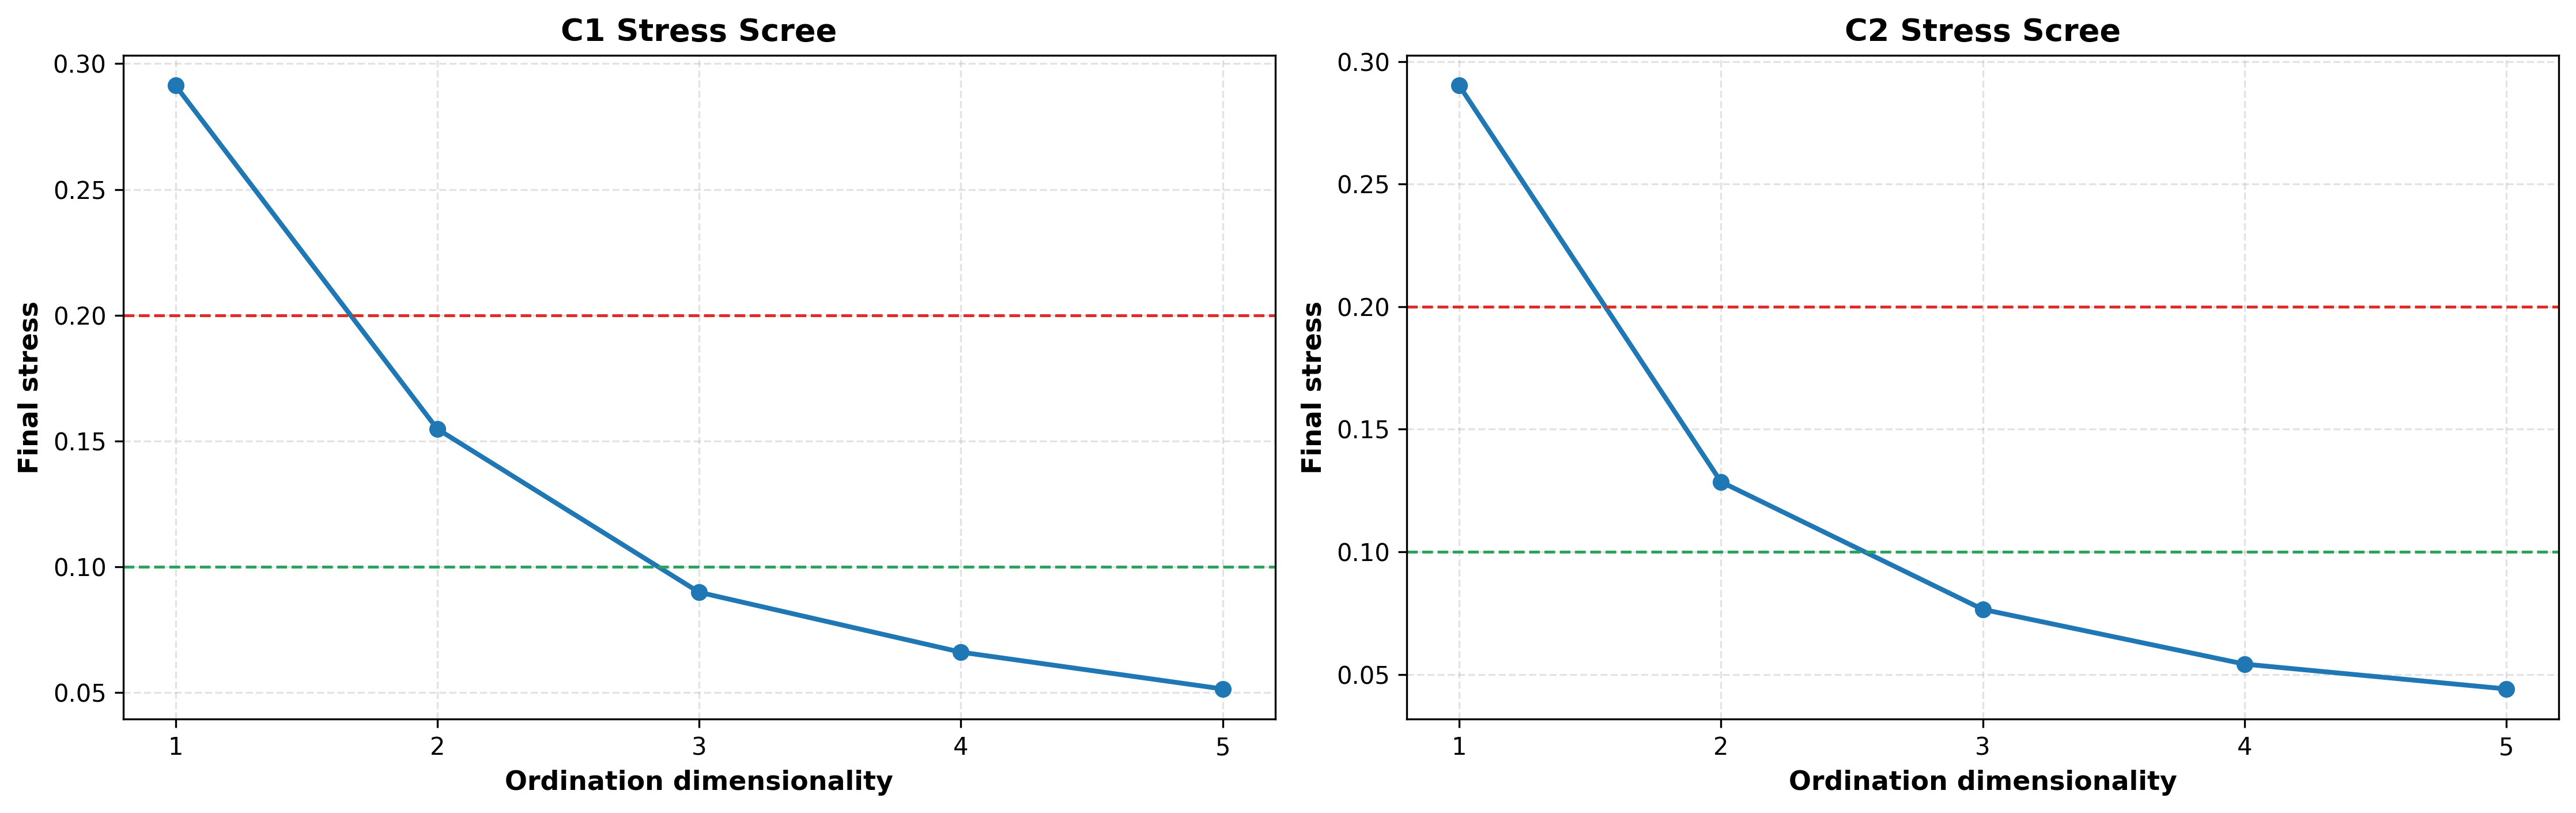

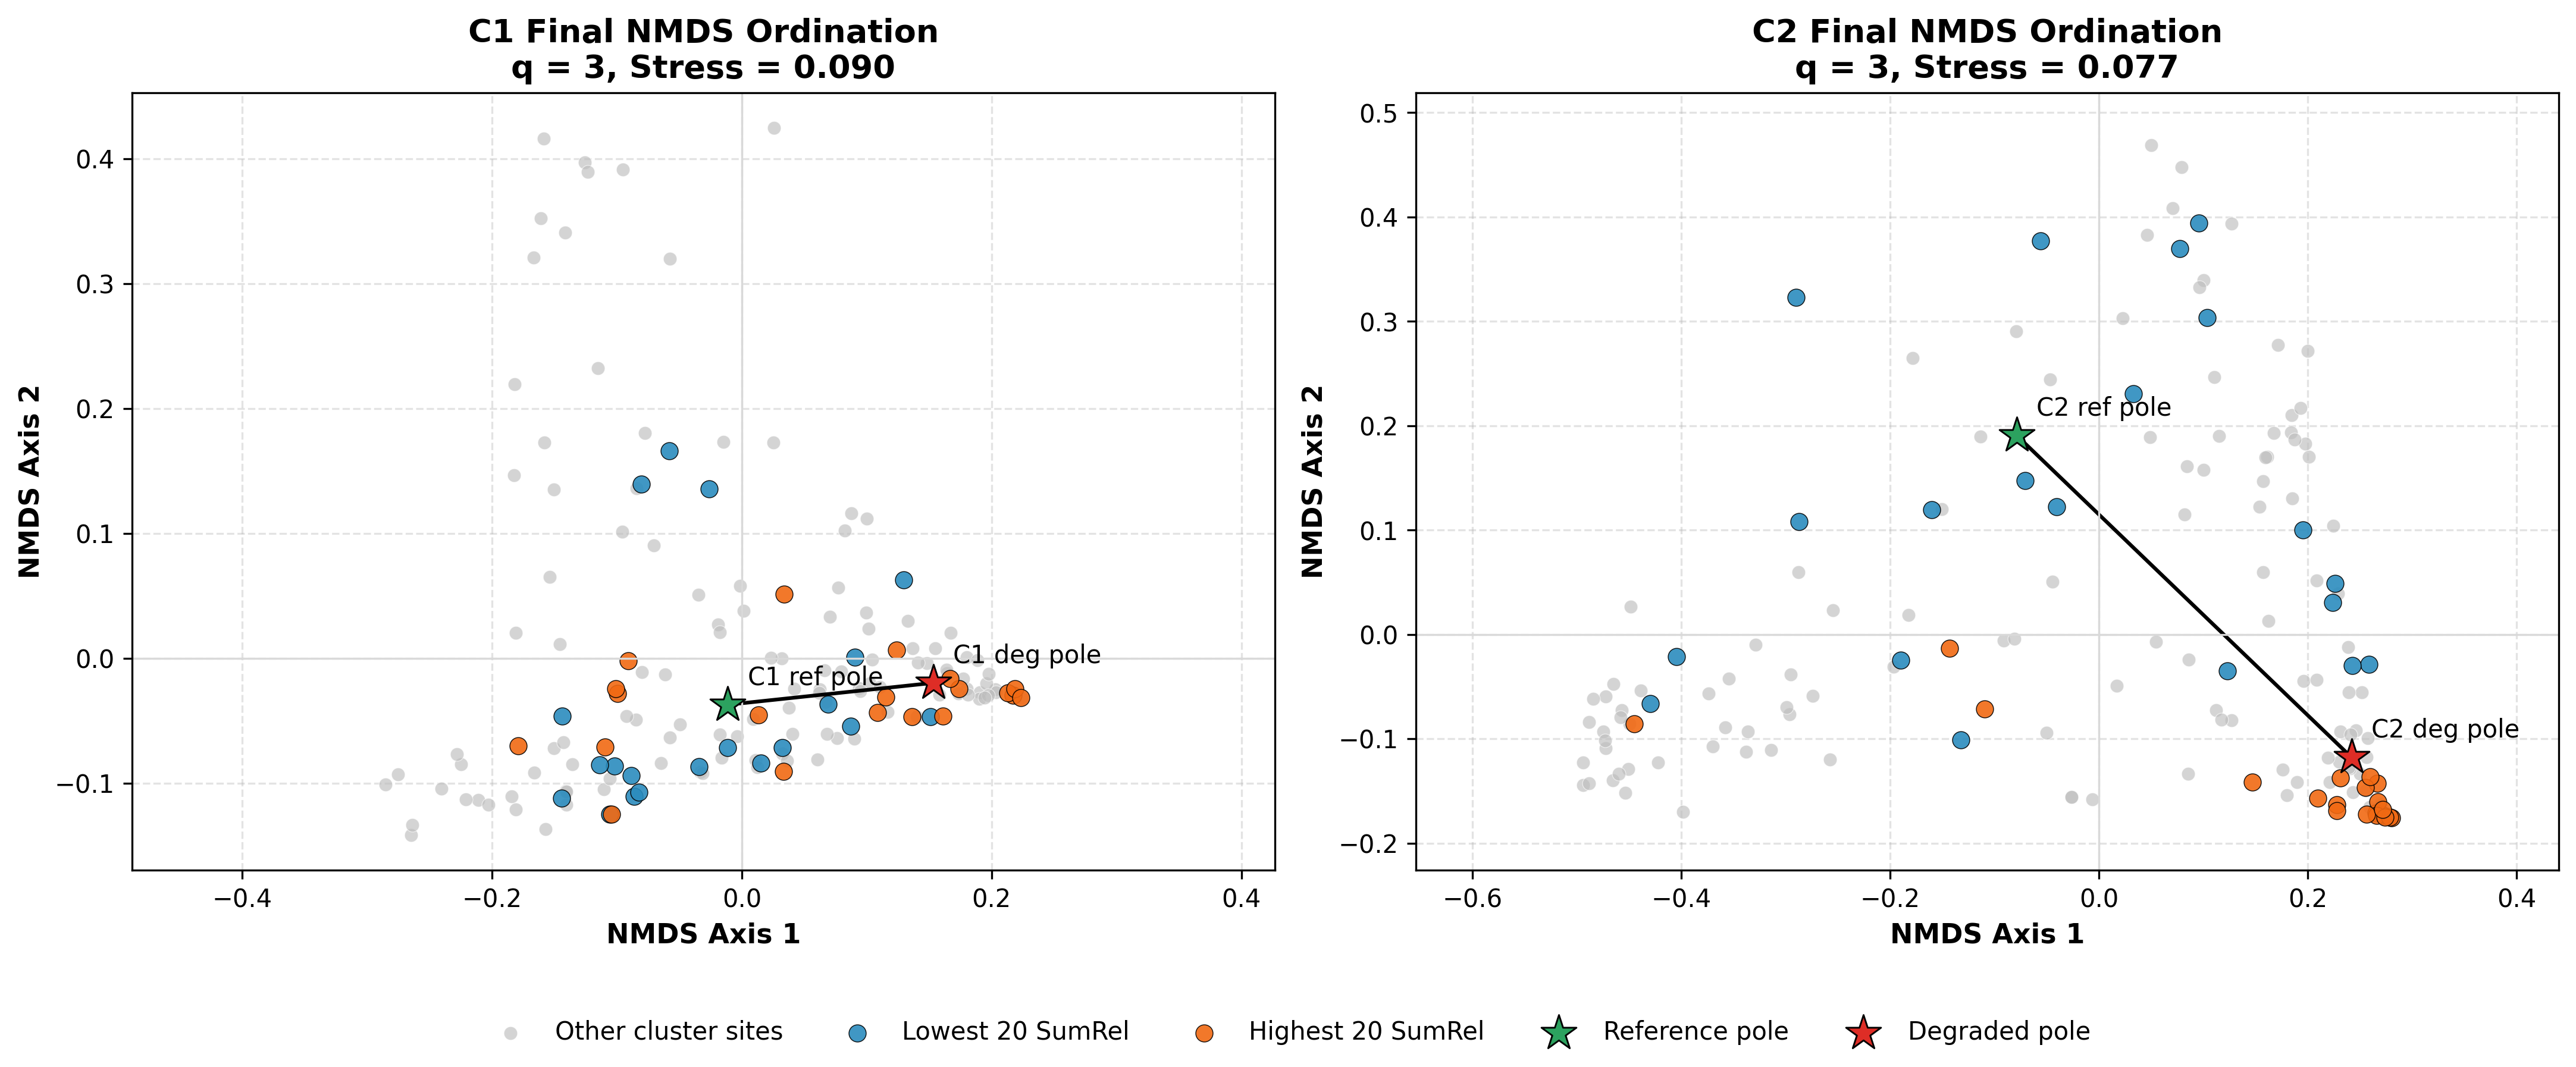

In [114]:
display(shepard_diagram_figure)

display(stress_scree_figure)

display(ordination_figure)
